## Introdução

Neste trabalho, analisamos uma base de dados sobre a experiência do cliente em compras, com foco no Net Promoter Score (NPS). O objetivo é avaliar como fatores operacionais — como atrasos na entrega, contatos com o suporte e volume de reclamações — influenciam a satisfação dos clientes, gerando insights para apoiar a tomada de decisão.

## 1. Importação de bibliotecas, configurações iniciais e carregamento dos dados

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)

from pathlib import Path

BASE_DIR = Path.cwd().parent
df = pd.read_csv(BASE_DIR / 'data' / 'desafio_nps_fase_1.csv')

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## 2. Entendimento e verificação da qualidade dos dados

In [25]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


In [26]:
# Verifica nulos
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [27]:
# Verifica se existem registros duplicados
df.duplicated().sum()

np.int64(0)

## 3. Feature engineering (Classificando NPS de acordo com as notas)

In [28]:
# Função para classificar as notas do NPS
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'
    
# Classifica os registros de acordo com suas notas do NPS
df['classificacao_nps'] = df['nps_score'].apply(classificar_nps)

# Retorna a porcentagem de cada classificação
df['classificacao_nps'].value_counts(normalize=True)

classificacao_nps
Detrator    0.7404
Neutro      0.1792
Promotor    0.0804
Name: proportion, dtype: float64

## 4. Correlação entre as colunas numéricas

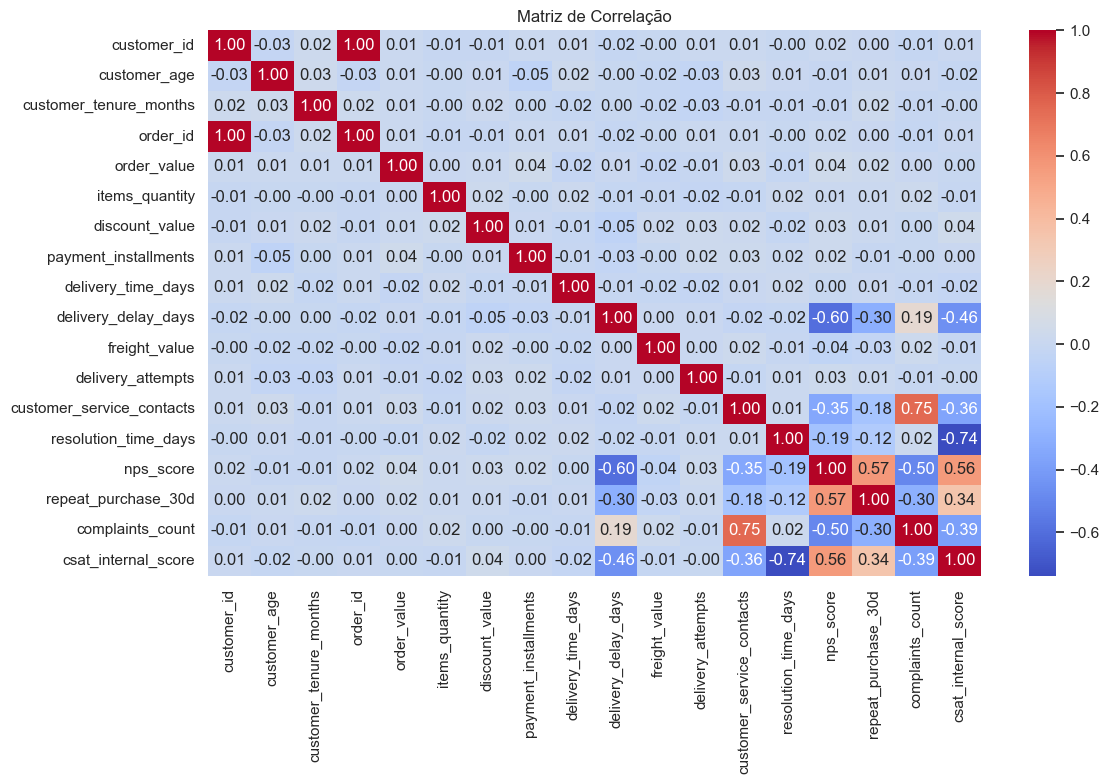

In [29]:
# Gera matriz de correlação entre todas as variáveis numéricas
corr = df.corr(numeric_only=True)
corr['nps_score'].sort_values()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

In [30]:
# Verifica a correlação da nota do NPS com as demais variáveis numéricas
corr_nps = corr['nps_score'].sort_values(ascending=False)
corr_nps

nps_score                    1.000000
repeat_purchase_30d          0.570324
csat_internal_score          0.563952
order_value                  0.036990
delivery_attempts            0.027680
discount_value               0.025104
payment_installments         0.023718
customer_id                  0.015162
order_id                     0.015162
items_quantity               0.011468
delivery_time_days           0.000925
customer_tenure_months      -0.009711
customer_age                -0.009936
freight_value               -0.041087
resolution_time_days        -0.191392
customer_service_contacts   -0.350845
complaints_count            -0.496800
delivery_delay_days         -0.597260
Name: nps_score, dtype: float64

## 5. Análise das médias por Classificação de NPS

In [31]:
# Verifica as médias de acordo com a classificação do NPS
classificacao_nps = df.groupby('classificacao_nps').mean(numeric_only=True)
classificacao_nps

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
classificacao_nps,,,,,,,,,,,,,,,,,,
Detrator,1236.515937,43.309562,61.575365,51236.515937,428.985446,3.494868,29.631248,5.968125,7.995678,2.534306,38.401091,1.992977,1.694219,5.793625,3.257699,0.000000,4.622907,2.340465
Neutro,1306.098214,43.446429,59.506696,51306.098214,447.334554,3.352679,29.356808,6.191964,8.120536,1.395089,37.908058,2.044643,1.129464,4.832589,6.893750,0.037946,2.986607,4.230357
Promotor,1255.358209,44.079602,63.039801,51255.358209,453.688607,3.512438,31.665473,5.915423,8.044776,0.756219,37.210498,2.034826,0.781095,4.104478,9.095025,1.000000,2.393035,5.604975


## 6. Dias de atraso na entrega vs Classificação NPS

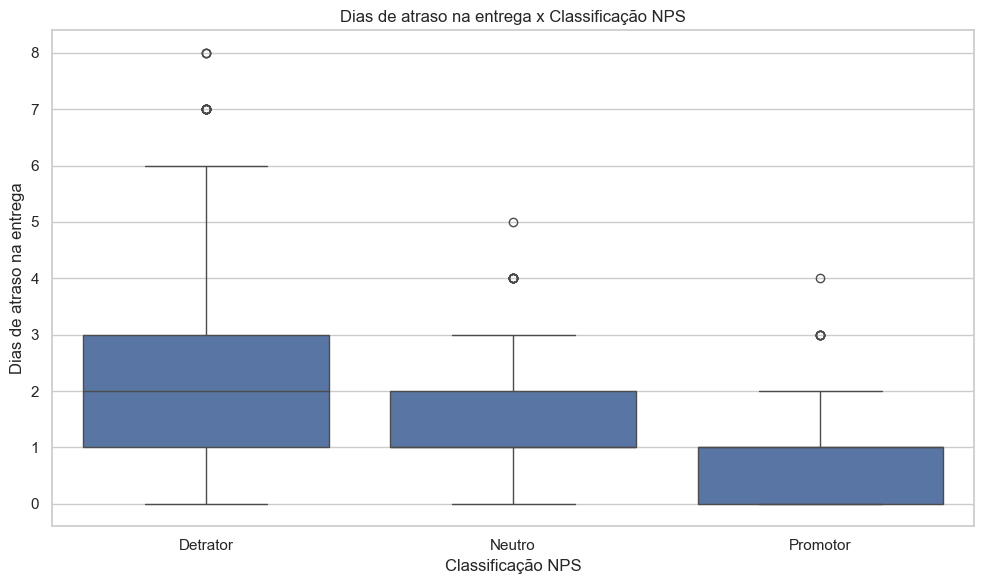

In [32]:
sns.boxplot(data=df, x='classificacao_nps', y='delivery_delay_days', order=['Detrator', 'Neutro', 'Promotor'])
plt.title('Dias de atraso na entrega x Classificação NPS')
plt.xlabel('Classificação NPS')
plt.ylabel('Dias de atraso na entrega')
plt.tight_layout()
plt.show()

In [33]:
# Verifica a distribuição das faixas de atraso por classificação de NPS
df['faixas_atraso'] = pd.cut(
    df['delivery_delay_days'],
    bins=[-1, 0, 2, 5, 100],
    labels=['0 dias', '1-2 dias', '3-5 dias', '6+ dias']
)

analise_atraso = pd.crosstab(df['faixas_atraso'], df['classificacao_nps'], normalize='index')
analise_atraso

classificacao_nps,Detrator,Neutro,Promotor
faixas_atraso,,,
0 dias,0.364621,0.324910,0.310469
1-2 dias,0.677240,0.237113,0.085646
3-5 dias,0.927552,0.064764,0.007684
6+ dias,1.000000,0.000000,0.000000


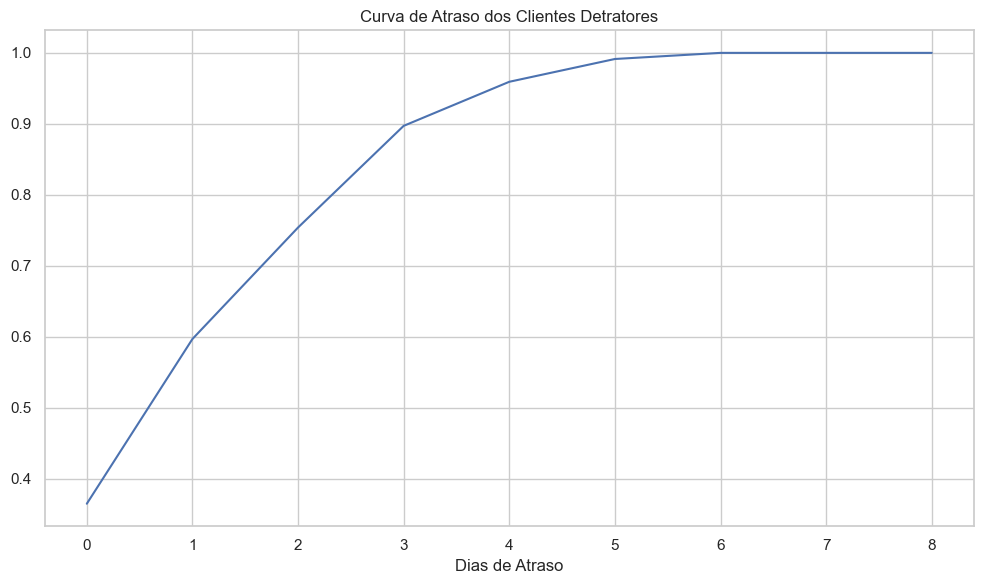

In [48]:
# Verifica a curva de atrasos dos detratores
df.groupby('delivery_delay_days')['classificacao_nps'].apply(lambda x: (x=='Detrator').mean()).plot()

plt.title('Curva de Atraso dos Clientes Detratores')
plt.xlabel('Dias de Atraso')
plt.tight_layout()
plt.show()

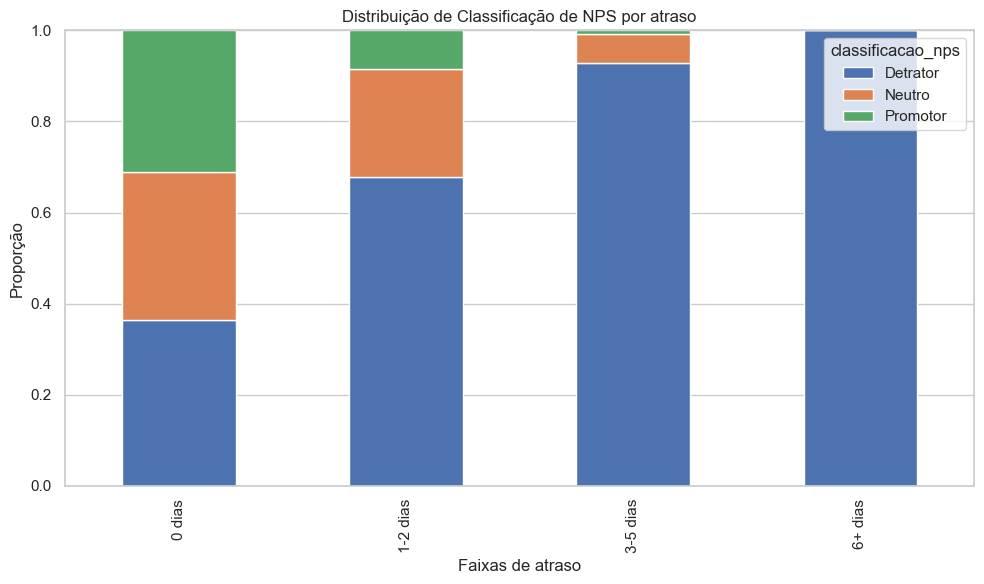

In [35]:
analise_atraso.plot(kind='bar', stacked=True)
plt.title('Distribuição de Classificação de NPS por atraso')
plt.xlabel('Faixas de atraso')
plt.ylabel('Proporção')
plt.tight_layout()
plt.show()

Clientes Detratores concentram-se em maiores atrasos e dominam as faixas acima de 3 dias, enquanto Promotores estão majoritariamente associados a entregas no prazo ou com atrasos mínimos.

## 7. Contatos com suporte vs Classificação NPS

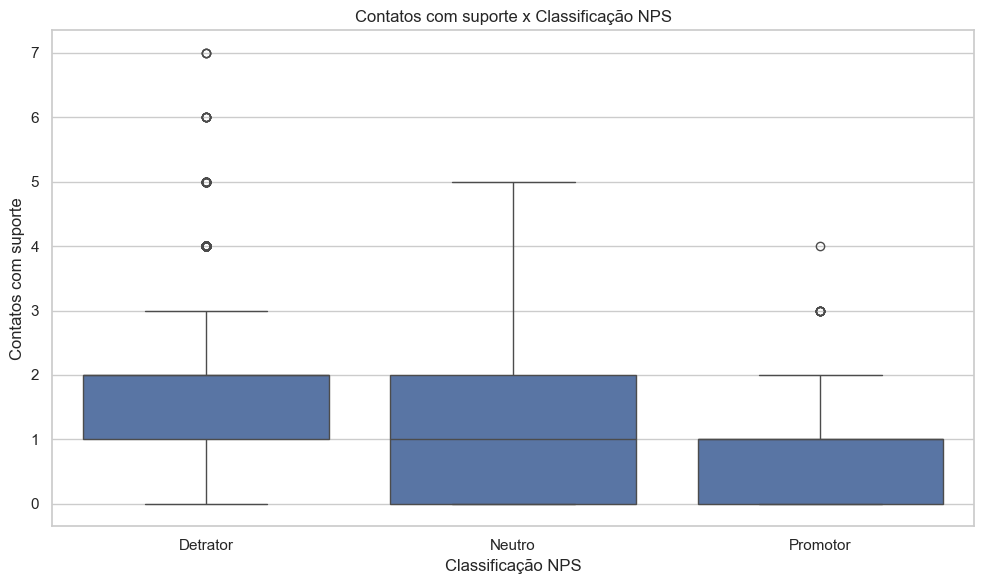

In [36]:
sns.boxplot(data=df, x='classificacao_nps', y='customer_service_contacts', order=['Detrator', 'Neutro', 'Promotor'])
plt.title('Contatos com suporte x Classificação NPS')
plt.xlabel('Classificação NPS')
plt.ylabel('Contatos com suporte')
plt.tight_layout()
plt.show()

In [37]:
# Verifica a média de contatos por classificação de NPS
df.groupby('classificacao_nps')['customer_service_contacts'].mean()

classificacao_nps
Detrator    1.694219
Neutro      1.129464
Promotor    0.781095
Name: customer_service_contacts, dtype: float64

In [38]:
# Verifica a distribuição das faixas de contato com o suporte por classificação de NPS
df['faixa_contatos'] = pd.cut(
    df['customer_service_contacts'],
    bins=[-1, 0, 2, 4, 10],
    labels=['0', '1-2', '3-4', '5+']
)

analise_contatos = pd.crosstab(df['faixa_contatos'], df['classificacao_nps'], normalize='index')
analise_contatos

classificacao_nps,Detrator,Neutro,Promotor
faixa_contatos,,,
0,0.592058,0.238267,0.169675
1-2,0.741758,0.190934,0.067308
3-4,0.896861,0.082960,0.020179
5+,0.977273,0.022727,0.000000


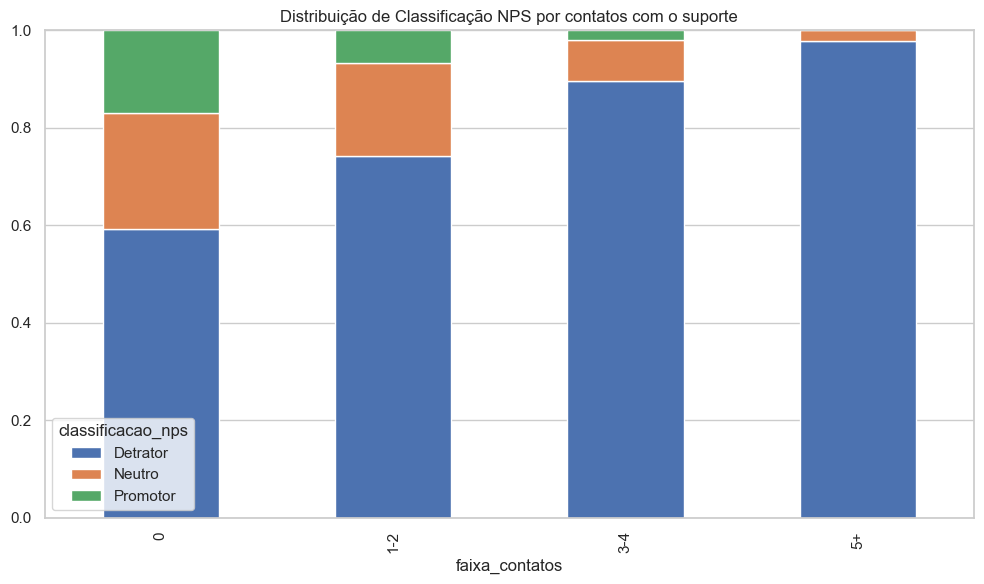

In [39]:
analise_contatos.plot(kind='bar', stacked=True)
plt.title('Distribuição de Classificação NPS por contatos com o suporte')
plt.tight_layout()
plt.show()

Clientes Detratores apresentam maior recorrência de contatos com o suporte, enquanto Promotores concentram-se em faixas de baixo ou nenhum contato, indicando uma experiência mais fluida.

## 8. Quantidade de reclamações vs Classificação NPS

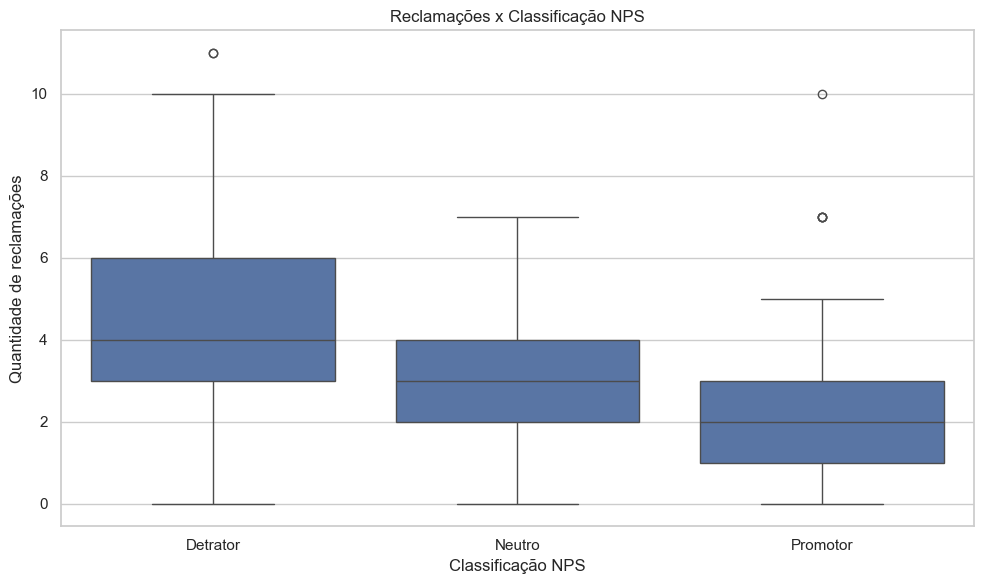

In [40]:
# Verifica a quantidade de reclamações por classificação do NPS
sns.boxplot(data=df, x='classificacao_nps', y='complaints_count', order=['Detrator', 'Neutro', 'Promotor'])
plt.title('Reclamações x Classificação NPS')
plt.xlabel('Classificação NPS')
plt.ylabel('Quantidade de reclamações')
plt.tight_layout()
plt.show()

In [41]:
# Verifica a distribuição de números de reclamações por classificação de NPS
pd.crosstab(df['complaints_count'], df['classificacao_nps'], normalize='index')

classificacao_nps,Detrator,Neutro,Promotor
complaints_count,,,
0,0.043478,0.347826,0.608696
1,0.081967,0.500000,0.418033
2,0.433213,0.386282,0.180505
3,0.676529,0.242604,0.080868
4,0.811667,0.136667,0.051667
5,0.882883,0.096847,0.020270
6,0.936090,0.063910,0.000000
7,0.934911,0.041420,0.023669
8,1.000000,0.000000,0.000000


In [42]:
# Verifica a média de reclamações por classificação de NPS
df.groupby('classificacao_nps')['complaints_count'].mean()

classificacao_nps
Detrator    4.622907
Neutro      2.986607
Promotor    2.393035
Name: complaints_count, dtype: float64

Clientes Detratores concentram maior volume e variabilidade de reclamações, enquanto Promotores apresentam níveis mais baixos e estáveis, reforçando a relação entre experiência negativa e queda no NPS.

## 9. Recompra vs Classificação NPS

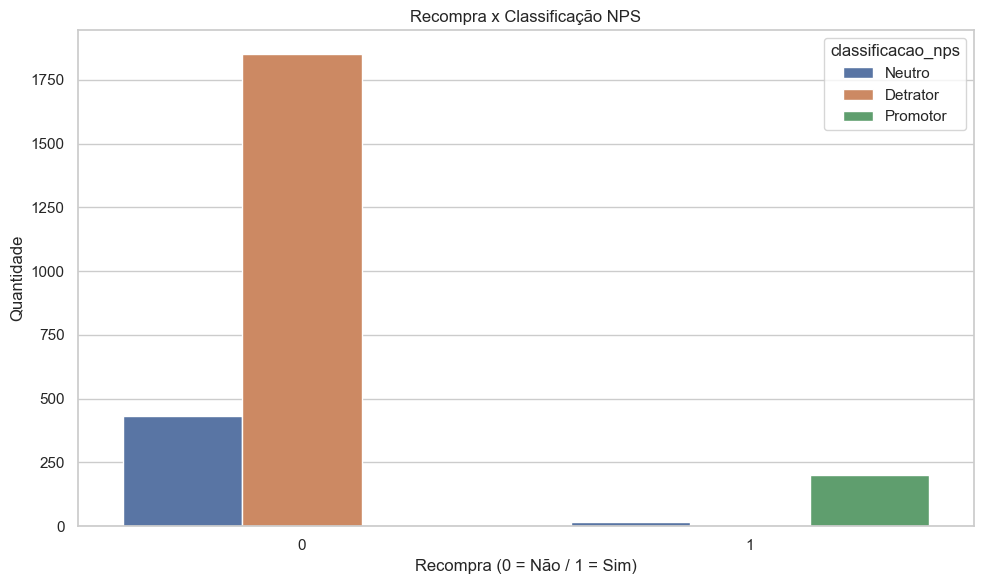

In [43]:
# Verifica a quantidade de recompras de acordo com a classificação do NPS
sns.countplot(data=df, x='repeat_purchase_30d', hue='classificacao_nps')
plt.title('Recompra x Classificação NPS')
plt.xlabel('Recompra (0 = Não / 1 = Sim)')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

Clientes Promotores concentram a quase totalidade das recompras em até 30 dias, enquanto Detratores e Neutros apresentam comportamento predominantemente de não recompra.

## 10. Índice de Satisfação do Cliente vs Nota NPS

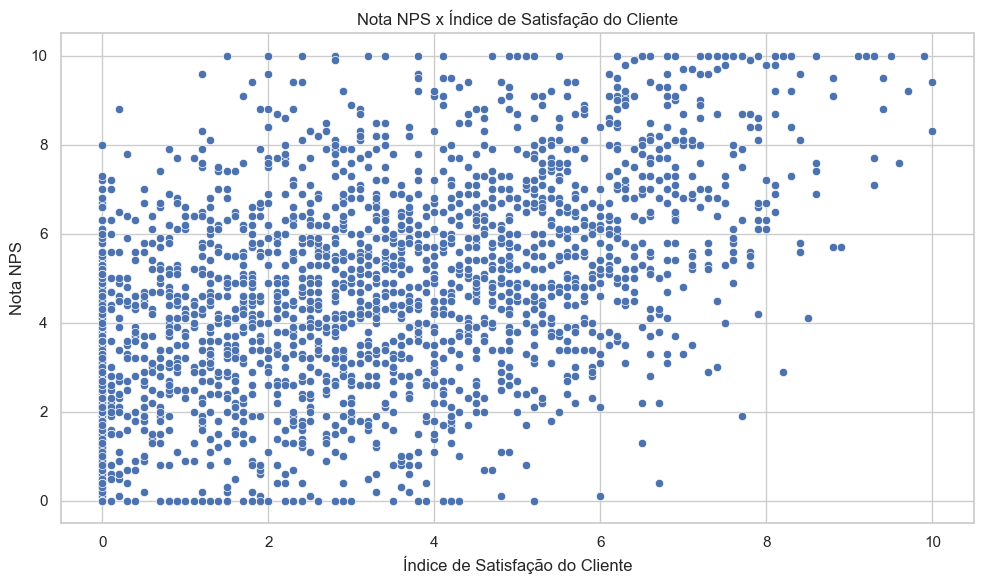

In [44]:
# Verifica a correlação entre a nota do NPS e o Índice de Satisfação do Cliente
sns.scatterplot(data=df, x='csat_internal_score', y='nps_score')
plt.title('Nota NPS x Índice de Satisfação do Cliente')
plt.xlabel('Índice de Satisfação do Cliente')
plt.ylabel('Nota NPS')
plt.tight_layout()
plt.show()

C:\Users\u1087373\AppData\Local\Temp\ipykernel_22324\2493059169.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


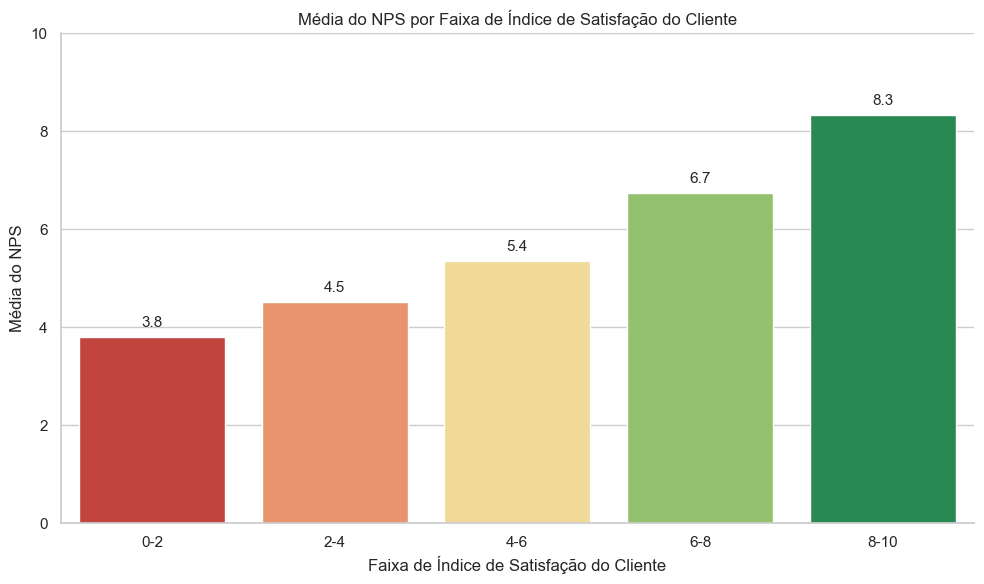

In [45]:
# Cria faixas de CSAT
df['csat_faixa'] = pd.cut(df['csat_internal_score'],
                          bins=[0, 2, 4, 6, 8, 10],
                          labels=['0-2', '2-4', '4-6', '6-8', '8-10'])

# Agrupa as faixas de CSAT com suas respectivas médias de NPS
df_agrupado = df.groupby('csat_faixa')['nps_score'].mean().reset_index()

# Paleta de cores do vermelho para o verde
cores = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']

sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_agrupado,
    x='csat_faixa',
    y='nps_score',
    palette=cores
)

# Insere os valores da média de NPS acima de cada barra
for i, linha in df_agrupado.iterrows():
    ax.text(i, linha['nps_score'] + 0.2,
            f"{linha['nps_score']:.1f}",
            ha='center', fontsize=11)

plt.title('Média do NPS por Faixa de Índice de Satisfação do Cliente')
plt.xlabel('Faixa de Índice de Satisfação do Cliente')
plt.ylabel('Média do NPS')
plt.ylim(0, 10)

sns.despine()
plt.tight_layout()
plt.show()

O aumento do CSAT está diretamente associado à elevação do NPS, sugerindo que iniciativas focadas na melhoria da experiência do cliente têm alto potencial de impacto na lealdade e recomendação.

## 11. Conclusões

### 11.1 Quais fatores parecem mais críticos para a satisfação?

Os dados indicam que a satisfação do cliente é principalmente impactada por fatores operacionais, com destaque para:

- <b>Atraso na entrega (principal fator)</b>
- <b>Número de contatos com o suporte</b>
- <b>Quantidade de reclamações</b>
- <b>Tempo de resolução de problemas</b>

O atraso se destaca como o fator mais crítico: clientes detratores apresentam, em média, <b>mais de 3 vezes o atraso dos promotores.</b>

Além disso, há um efeito acumulativo:

- Quanto mais problemas o cliente enfrenta (atraso + suporte + reclamação), menor a satisfação.

### 11.2 O que mais gera detratores?

O principal gerador de detratores é o atraso na entrega, especialmente quando combinado com outros atritos na experiência.

Evidências:

- Sem atraso → cerca de <b>36% de detratores</b>
- Até 2 dias → <b>~68% de detratores</b>
- 2 a 5 dias → <b>~93% de detratores</b>
- Acima de 5 dias → <b>100% de detratores</b>

Além disso:

- Clientes que entram mais vezes em contato com o suporte têm maior probabilidade de serem detratores
- Reclamações aumentam ainda mais esse risco

Conclusão:

Detratores são gerados principalmente por falhas operacionais recorrentes, não por eventos isolados.

###  11.3 Existe algum “ponto de ruptura” na experiência do cliente?

Sim, existe um ponto de ruptura claro.

- O ponto crítico ocorre a partir de aproximadamente <b>2 dias de atraso na entrega.</b>

A partir desse momento:

- A taxa de detratores ultrapassa <b>90%</b>
- A satisfação do cliente se deteriora rapidamente

Isso indica um <b>limite de tolerância do cliente:</b>

- Pequenos atrasos são parcialmente tolerados
- Atrasos acima de 2 dias causam perda significativa de confiança

### 11.4 Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

🔴 <b>Clientes Detratores</b>

Apresentam um padrão consistente:

- Atrasos na entrega (principalmente >2 dias)
- Múltiplos contatos com suporte
- Alta quantidade de reclamações
- Baixa satisfação geral (CSAT)

Perfil:

- Cliente que enfrentou vários problemas ao longo da jornada

🟢 <b>Clientes Promotores</b>

Tendem a ter uma experiência fluida:

- Entregas dentro do prazo ou com atraso mínimo
- Pouca ou nenhuma necessidade de contato com suporte
- Ausência de reclamações
- Alta avaliação de satisfação

Perfil:

- Cliente que não enfrentou problemas na experiência